<a href="https://colab.research.google.com/github/YaKhom/ML-Practice/blob/main/LogReg_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Логистическая регрессия

Обучим логистическую регрессию для предсказания того, откликнется клиент  
на рекламное предложение (target = 1) или нет (target = 0).

## Подлючение библиотек, загрузка и обзор данных

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [15]:
data = pd.read_csv('https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/clients_data.csv')

In [16]:
data.head()

,AGE,SOCSTATUS_WORK_FL,SOCSTATUS_PENS_FL,GENDER,CHILD_TOTAL,DEPENDANTS,PERSONAL_INCOME,LOAN_NUM_TOTAL,LOAN_NUM_CLOSED,LOAN_DLQ_NUM,TARGET
0,49,1,0,1,2,1,5000.0,1,1,2,0
1,32,1,0,1,3,3,12000.0,1,1,1,0
2,52,1,0,1,4,0,9000.0,2,1,0,0
3,39,1,0,1,1,1,25000.0,1,1,3,0
4,30,1,0,0,0,0,12000.0,2,1,2,0


In [17]:
from sklearn.model_selection import train_test_split

X = data.drop('TARGET', axis=1)
y = data['TARGET']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.7, random_state=123)

## Практика

**Задание**  
Выведите на экран количество объектов каждого класса. Сколько процентов объектов относятся к положительному классу?  
Ответ округлите до целого числа (например, если доля объектов положительного класса равна 0.412, в ответ запишите 41,  
имея в виду 41 процент).

In [18]:
positive_count = np.sum(y == 1)
total_count = len(y)

positive_percentage = round((positive_count / total_count) * 100)

print(positive_percentage)

12


Обучим логистическую регрессию с параметрами по умолчанию.

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

In [22]:
lr.fit(Xtrain, ytrain)

prediction = lr.predict(Xtest)

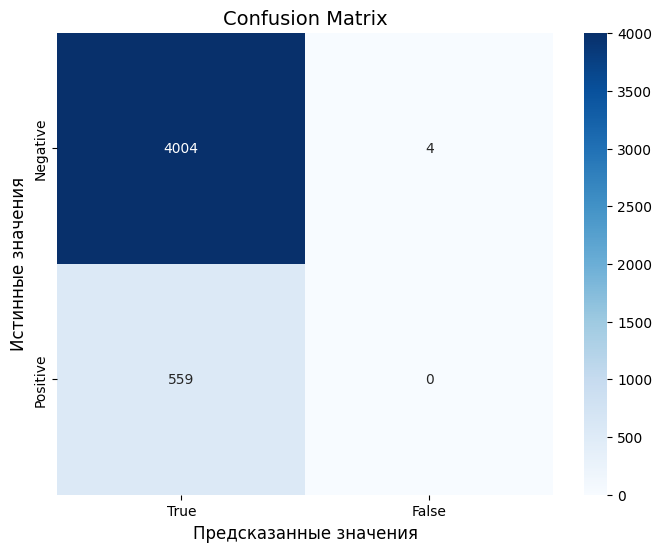

Confusion Matrix:
[[4004    4]
 [ 559    0]]


In [26]:
cm = confusion_matrix(ytest, prediction)

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['True', 'False'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Предсказанные значения', fontsize=12)
plt.ylabel('Истинные значения', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

print("Confusion Matrix:")
print(cm)

Метрику accuracy не стоит использовать при сильном дисбалансе классов. Поэтому посчитайте f1_score для оценки качества модели на тестовых данных.

f1_score принимает значения от 0 до 1. Чем ближе к 1, тем лучше модель.

In [25]:
from sklearn.metrics import f1_score

f1_score(ytest,prediction)

0.0

**Вопрос**  
Чему равен `f1_score`?

Удивительно, да?

Давайте разберемся, почему качество такое низкое.

Предскажем вероятности классов с помощью обученной логистической регрессии на тестовых данных.

In [27]:
probs_test = lr.predict_proba(Xtest)

probs_test[:10]

array([[0.93860052, 0.06139948],
       [0.90059186, 0.09940814],
       [0.71082803, 0.28917197],
       [0.78458585, 0.21541415],
       [0.87089445, 0.12910555],
       [0.9585094 , 0.0414906 ],
       [0.93632178, 0.06367822],
       [0.96561689, 0.03438311],
       [0.94889185, 0.05110815],
       [0.93091044, 0.06908956]])

По вероятностям видно, что вероятности отнесения к положительному классу очень низкие.

Попробуем изменить порог для перевода вероятности в классы.

**Вопрос**  
Чему равен `f1_score`, если все объекты с вероятностью не меньшей 0.1, относить к положительному классу?

Ответ округлите до сотых.

In [28]:
probs_positive = probs_test[:, 1]

# Устанавливаем порог 0.1
threshold = 0.1
y_pred = (probs_positive >= threshold).astype(int)

# Вычисляем F1-score
f1 = f1_score(ytest, y_pred)

# Округляем до сотых
print(f"F1-score при пороге 0.1: {f1:.2f}")

F1-score при пороге 0.1: 0.25


У обученной модели можно посмотреть веса (как и в линейной регрессии).  
Выведем на экран веса модели (`model.coef_`, `model.intercept_`).

In [29]:
lr.coef_, lr.intercept_

(array([[-4.61786358e-02, -1.47051283e-01, -8.61126244e-02,
         -1.54075703e-01,  1.91465958e-01, -1.41678590e-01,
          2.01720015e-05, -6.01039642e-02, -2.31268961e-01,
          2.92922844e-01]]),
 array([-0.24167938]))

Создайте `pd.DataFrame`, где в первом столбце стоят названия признаков, а во втором - их веса (так удобнее анализировать результат).  
Отсортируйте таблицу по убыванию весов.

**Вопрос**  
Какой признак имеет наибольший положительный вес?

In [30]:
# Получаем названия признаков (если Xtrain - DataFrame)
if hasattr(Xtrain, 'columns'):
    feature_names = Xtrain.columns.tolist()
else:
    # Если Xtrain - массив numpy, создаем имена признаков
    feature_names = [f'feature_{i}' for i in range(Xtrain.shape[1])]

# Получаем веса признаков (коэффициенты модели)
# У модели логистической регрессии веса хранятся в lr.coef_
# lr.coef_ имеет форму (1, n_features) для бинарной классификации
weights = lr.coef_[0]  # берем первую (и единственную) строку

# Создаем DataFrame
weights_df = pd.DataFrame({
    'Признак': feature_names,
    'Вес': weights
})

# Сортируем по убыванию весов
weights_df = weights_df.sort_values('Вес', ascending=False).reset_index(drop=True)

# Выводим результат
print("Веса признаков (отсортированы по убыванию):")
print(weights_df)

# Находим признак с наибольшим положительным весом
max_weight_feature = weights_df.iloc[0]['Признак']
max_weight_value = weights_df.iloc[0]['Вес']

print(f"\nПризнак с наибольшим положительным весом: {max_weight_feature}")
print(f"Значение веса: {max_weight_value:.6f}")

Веса признаков (отсортированы по убыванию):
             Признак       Вес
0       LOAN_DLQ_NUM  0.292923
1        CHILD_TOTAL  0.191466
2    PERSONAL_INCOME  0.000020
3                AGE -0.046179
4     LOAN_NUM_TOTAL -0.060104
5  SOCSTATUS_PENS_FL -0.086113
6         DEPENDANTS -0.141679
7  SOCSTATUS_WORK_FL -0.147051
8             GENDER -0.154076
9    LOAN_NUM_CLOSED -0.231269

Признак с наибольшим положительным весом: LOAN_DLQ_NUM
Значение веса: 0.292923


## Бонус

**Задание 1**  
Подберите порог для перевода вероятностей в классы, дающий максимальное значение `f1_score`.

In [ ]:
# ваш код здесь

**Задание 2**  
Во вложенном цикле подберите одновременно коэффициент регуляризации `C` у логистической регрессии и порог для перевода вероятностей в классы, дающие максимальное значение `f1_score`.

По-хорошему, чтобы не переобучиться, эти величины надо подбирать не по тесту, а по отдельной выборке.

Поэтому разобъем данные изначально на три части: `Xtrain`, `Xval`, `Xtest`.

*   В цикле при подборе `С` и порога будем обучаться по `Xtrain`, а предсказывать и измерять качество по `Xval`.

*   Качество итоговой модели с найденными `C` и порогом измерьте по `Xtest`.

Так не переобучимся!


In [ ]:
Xtrain_new, Xval, ytrain_new, yval = train_test_split(Xtrain, ytrain, train_size=0.7, random_state=123)

# ваш код для подбора C и порога здесь

In [ ]:
model = LogisticRegression(C = ...)

model.fit(Xtrain, ytrain) # обучаемся на всех тренировочных данных

prediction = model.predict_proba(Xtest)

classes = ... # переведите полученные вероятности в классы по найденному порогу

In [ ]:
# вычислите значение f1_score на тестовых данных